# Arya Phones ? Round-by-Round Customer Simulation

This notebook runs round simulations with generated category-complete supplier portfolios.
Teams that finish below the previous round's average realized profit swap to the next generated portfolio.


In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('../..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings('ignore')

from server.app.service import get_tables
from server.app.settings import GAME_SETTINGS
from server.app.beta_density import BetaDensity
from server.app.mnl_market import BuyerProfile, run_mnl_market
from server.app.customer_segment import CustomerSegment

suppliers_df, users_df = get_tables()
N = len(users_df)
print(f'Suppliers: {len(suppliers_df)}  |  Segments: {N}')
PALETTE = ['#2563eb','#dc2626','#059669','#7c3aed','#d97706','#0891b2','#be123c','#65a30d']


Suppliers: 18  |  Segments: 20


In [2]:
# Helpers

import itertools
import random as _random
from server.app.audit import run_audit, AuditResult

RANDOM_SEED = 20260413
RANDOM_GROUP_COUNT = 10

def _category_groups():
    if 'category' not in suppliers_df.columns:
        return {}
    df = suppliers_df[['supplier_id', 'category']].dropna().copy()
    df['supplier_id'] = df['supplier_id'].astype(str)
    df['category'] = df['category'].astype(str).str.strip()
    cats = [c for c in df['category'].drop_duplicates().tolist() if c and c.lower() != 'nan']
    return {cat: df[df['category'] == cat]['supplier_id'].tolist() for cat in cats}

CATEGORY_GROUPS = _category_groups()
CATEGORIES = list(CATEGORY_GROUPS)

def avg_attrs(picks):
    pick_set = {str(p) for p in picks}
    sel = suppliers_df[suppliers_df['supplier_id'].astype(str).isin(pick_set)]
    if sel.empty:
        return {}
    cols = ['env_risk', 'social_risk', 'cost_score', 'strategic', 'child_labor', 'banned_chem']
    return {c: float(sel[c].mean()) for c in cols if c in sel.columns}

def category_complete(picks):
    if not CATEGORY_GROUPS:
        return len(picks) > 0
    pick_set = {str(p) for p in picks}
    for ids in CATEGORY_GROUPS.values():
        if len(pick_set.intersection(ids)) != 1:
            return False
    all_category_ids = set().union(*[set(ids) for ids in CATEGORY_GROUPS.values()])
    return pick_set.issubset(all_category_ids)

def risk_violation(picks):
    a = avg_attrs(picks)
    if not a:
        return float('inf')
    return max(0.0, a.get('env_risk', 99) - GAME_SETTINGS.env_cap) + max(0.0, a.get('social_risk', 99) - GAME_SETTINGS.social_cap)

def is_feasible(picks):
    a = avg_attrs(picks)
    return (category_complete(picks)
            and a.get('env_risk', 99) <= GAME_SETTINGS.env_cap + 1e-9
            and a.get('social_risk', 99) <= GAME_SETTINGS.social_cap + 1e-9)

def repair_supplier_group(picks, rng=None):
    rng = rng or _random.Random(RANDOM_SEED)
    if not CATEGORY_GROUPS:
        return [str(p) for p in picks]
    pick_set = {str(p) for p in picks}
    current = []
    for cat in CATEGORIES:
        in_cat = [sid for sid in CATEGORY_GROUPS[cat] if sid in pick_set]
        current.append(in_cat[0] if in_cat else rng.choice(CATEGORY_GROUPS[cat]))

    for _ in range(50):
        if is_feasible(current):
            return current
        best = current
        best_key = (risk_violation(current), avg_attrs(current).get('cost_score', 99))
        for idx, cat in enumerate(CATEGORIES):
            for sid in CATEGORY_GROUPS[cat]:
                if sid == current[idx]:
                    continue
                trial = list(current)
                trial[idx] = sid
                key = (risk_violation(trial), avg_attrs(trial).get('cost_score', 99))
                if key < best_key:
                    best = trial
                    best_key = key
        if best == current:
            break
        current = best
    return current

def format_group(picks):
    return '[' + ','.join(str(p) for p in picks) + ']'

def make_random_supplier_sets(n=10, seed=RANDOM_SEED):
    rng = _random.Random(seed)
    out = {}
    seen = set()
    if not CATEGORY_GROUPS:
        for sid in suppliers_df['supplier_id'].astype(str).tolist()[:n]:
            out[f'G{len(out)+1:02d} [{sid}]'] = [sid]
        return out
    attempts = 0
    while len(out) < n and attempts < n * 500:
        attempts += 1
        picks = [rng.choice(CATEGORY_GROUPS[cat]) for cat in CATEGORIES]
        picks = repair_supplier_group(picks, rng)
        key = tuple(picks)
        if key in seen or not is_feasible(picks):
            continue
        seen.add(key)
        out[f'G{len(out)+1:02d} {format_group(picks)}'] = picks
    for combo in itertools.product(*[CATEGORY_GROUPS[cat] for cat in CATEGORIES]):
        picks = repair_supplier_group(combo, rng)
        key = tuple(picks)
        if key not in seen and is_feasible(picks):
            seen.add(key)
            out[f'G{len(out)+1:02d} {format_group(picks)}'] = picks
        if len(out) >= n:
            break
    return out

PORTFOLIOS = make_random_supplier_sets(RANDOM_GROUP_COUNT, RANDOM_SEED)
PORTFOLIO_ITEMS = list(PORTFOLIOS.items())

def portfolio(idx):
    name, picks = PORTFOLIO_ITEMS[idx % len(PORTFOLIO_ITEMS)]
    return name, list(picks)

def team_entry(name, group_idx, price):
    _, picks = portfolio(group_idx)
    return {'name': name, 'picks': picks, 'price': price}

def portfolio_index_for(picks):
    norm = tuple(repair_supplier_group(picks))
    for idx, (_, pp) in enumerate(PORTFOLIO_ITEMS):
        if tuple(pp) == norm:
            return idx
    return 0

def make_segments(alpha=3.0, beta=3.0):
    bd = BetaDensity(alpha=max(0.01, alpha), beta=max(0.01, beta))
    us = users_df.sort_values('w_cost').reset_index(drop=True)
    return [
        CustomerSegment(
            segment_id=str(row['user_id']),
            density=float(bd.density_at((i + 0.5) / N)),
            w_env=float(row.get('w_env', 0)),
            w_social=float(row.get('w_social', 0)),
            w_cost=float(row.get('w_cost', 1)),
            w_low_quality=float(row.get('w_low_quality', 0)),
        )
        for i, (_, row) in enumerate(us.iterrows())
    ]

def buyer_profile(name, picks, price):
    picks = repair_supplier_group(picks)
    a = avg_attrs(picks)
    return BuyerProfile(
        team_name=name, price_per_user=float(price),
        avg_env=a.get('env_risk', 0), avg_social=a.get('social_risk', 0),
    )

def run_round(team_specs, alpha=3.0, beta=3.0, delta=0.1, u_outside=-3.0,
              excluded_teams=None):
    # Returns (round_df, segment_df).
    # excluded_teams: set/list of team names excluded by audit this round.
    team_specs = [(name, repair_supplier_group(picks), price) for name, picks, price in team_specs]
    excluded = set(excluded_teams or [])
    active_specs = [s for s in team_specs if s[0] not in excluded and is_feasible(s[1])]

    segs = make_segments(alpha, beta)
    profiles = [buyer_profile(name, picks, price) for name, picks, price in active_specs]
    result = run_mnl_market(profiles, segs, delta=delta, u_outside=u_outside)

    us_s = users_df.sort_values('w_cost').reset_index(drop=True)
    seg_idx  = {str(r['user_id']): i+1 for i, (_, r) in enumerate(us_s.iterrows())}
    seg_wc   = {str(r['user_id']): float(r['w_cost']) for _, r in us_s.iterrows()}
    total_d  = sum(s.density for s in segs)

    team_rows = []
    for name, picks, price in team_specs:
        a = avg_attrs(picks)
        if name in excluded or not is_feasible(picks):
            team_rows.append({
                'team': name, 'picks': ','.join(picks), 'feasible': is_feasible(picks),
                'price': price, 'delta': delta, 'alpha': alpha, 'beta': beta,
                'audit_excluded': name in excluded,
                'demand_share_pct': 0.0, 'effective_users': 0.0,
                'unit_margin': 0.0, 'realized_profit': 0.0, 'realized_utility': 0.0,
                'avg_env': round(a.get('env_risk', 0), 3),
                'avg_social': round(a.get('social_risk', 0), 3),
                'avg_cost': round(a.get('cost_score', 0), 3),
                'avg_child_labor': round(a.get('child_labor', 0), 3),
                'avg_banned_chem': round(a.get('banned_chem', 0), 3),
            })
            continue
        br = result.buyer_results.get(name)
        demand = br.total_demand if br else 0.0
        eff    = demand * N
        margin = price - GAME_SETTINGS.cost_scale * a.get('cost_score', 0)
        team_rows.append({
            'team': name, 'picks': ','.join(picks), 'feasible': is_feasible(picks),
            'price': price, 'delta': delta, 'alpha': alpha, 'beta': beta,
            'audit_excluded': False,
            'demand_share_pct': round(demand * 100, 2),
            'effective_users':  round(eff, 3),
            'unit_margin':      round(margin, 2),
            'realized_profit':  round(eff * margin, 2),
            'realized_utility': round((br.realized_utility * N) if br else 0.0, 3),
            'avg_env':          round(a.get('env_risk', 0), 3),
            'avg_social':       round(a.get('social_risk', 0), 3),
            'avg_cost':         round(a.get('cost_score', 0), 3),
            'avg_child_labor':  round(a.get('child_labor', 0), 3),
            'avg_banned_chem':  round(a.get('banned_chem', 0), 3),
        })

    seg_rows = []
    for alloc in result.segment_allocations:
        norm_d = alloc.density / max(total_d, 1e-12)
        for name, picks, price in active_specs:
            seg_rows.append({
                'team': name, 'segment_id': alloc.segment_id,
                'segment_index': seg_idx.get(alloc.segment_id, 0),
                'w_cost': seg_wc.get(alloc.segment_id, 0),
                'density': round(norm_d, 5),
                'mnl_share': round(alloc.shares.get(name, 0), 4),
                'mnl_share_pct': round(alloc.shares.get(name, 0) * 100, 2),
            })

    return pd.DataFrame(team_rows), pd.DataFrame(seg_rows) if seg_rows else pd.DataFrame()

def run_scenario(name, rounds_cfg, delta_schedule=None,
                  audit_probability=0.0, catch_probability=1.0, audit_seed=0,
                  adaptive_swap=True):
    all_r, all_s = [], []
    portfolio_cursor = {}
    last_profit = {}
    prev_round_avg = None

    for i, rnd in enumerate(rounds_cfg):
        rno = rnd['round_no']
        raw_teams = rnd['teams']
        alpha = rnd.get('alpha', 3.0)
        beta  = rnd.get('beta', 3.0)
        delta = delta_schedule[i] if delta_schedule else rnd.get('delta', 0.1)
        ap    = rnd.get('audit_prob', audit_probability)
        cp    = rnd.get('catch_prob', catch_probability)

        specs = []
        for t in raw_teams:
            tname = t['name']
            price = t['price']
            if tname not in portfolio_cursor:
                portfolio_cursor[tname] = portfolio_index_for(t.get('picks', []))
            if adaptive_swap and prev_round_avg is not None and last_profit.get(tname, prev_round_avg) < prev_round_avg - 1e-9:
                portfolio_cursor[tname] = (portfolio_cursor[tname] + 1) % len(PORTFOLIO_ITEMS)
            _, picks = portfolio(portfolio_cursor[tname])
            specs.append((tname, picks, price))

        # Run audit if enabled
        excl = set(rnd.get('excluded_teams', []))
        audit_info = {}
        if ap > 0:
            tp  = {n: {'team': n, 'picked_suppliers': list(p)} for n, p, _ in specs}
            rng = _random.Random(audit_seed + rno)
            ar  = run_audit(tp, suppliers_df, audit_probability=ap,
                            catch_probability=cp, rng=rng)
            excl = excl | set(ar.excluded_teams)
            audit_info = {t: True for t in ar.excluded_teams}

        rdf, sdf = run_round(specs, alpha=alpha, beta=beta, delta=delta,
                             excluded_teams=excl)
        if audit_info:
            rdf['audit_excluded'] = rdf['team'].map(lambda t: audit_info.get(t, rdf.loc[rdf['team']==t, 'audit_excluded'].iloc[0]))
        rdf['round_no'] = rno; rdf['scenario'] = name
        if not sdf.empty:
            sdf['round_no'] = rno; sdf['scenario'] = name
        all_r.append(rdf)
        if not sdf.empty: all_s.append(sdf)

        last_profit = dict(zip(rdf['team'], rdf['realized_profit']))
        prev_round_avg = float(rdf['realized_profit'].mean()) if len(rdf) else None

    rdf_all = pd.concat(all_r, ignore_index=True)
    rdf_all['cum_profit']  = rdf_all.groupby('team')['realized_profit'].cumsum()
    rdf_all['cum_utility'] = rdf_all.groupby('team')['realized_utility'].cumsum()
    sdf_all = pd.concat(all_s, ignore_index=True) if all_s else pd.DataFrame()
    return rdf_all, sdf_all

def team_colors(teams):
    return {t: PALETTE[i % len(PALETTE)] for i, t in enumerate(sorted(teams))}

print('Random category-complete portfolios:')
for name, picks in PORTFOLIO_ITEMS:
    a = avg_attrs(picks)
    print(f"  {name:18s} env={a.get('env_risk',0):.2f} social={a.get('social_risk',0):.2f} cost={a.get('cost_score',0):.2f}")


Random category-complete portfolios:
  G01 [G,Q,R]        env=2.73 social=2.63 cost=3.36
  G02 [P,K,I]        env=2.59 social=2.59 cost=2.17
  G03 [J,E,O]        env=2.25 social=2.92 cost=2.58
  G04 [D,K,C]        env=2.69 social=2.86 cost=2.42
  G05 [A,E,L]        env=2.66 social=2.79 cost=2.29
  G06 [P,N,L]        env=2.70 social=1.40 cost=2.53
  G07 [M,B,F]        env=1.74 social=2.96 cost=3.29
  G08 [J,N,C]        env=2.46 social=2.13 cost=3.32
  G09 [D,B,C]        env=2.36 social=2.21 cost=3.27
  G10 [D,N,R]        env=2.44 social=0.89 cost=4.20
  G11 [A,B,C]        env=2.50 social=2.79 cost=3.21


## Scenario 1 ? Price War with Adaptive Supplier Swaps


In [3]:
S1 = [
    {'round_no':1,'teams':[team_entry('TeamA',0,100), team_entry('TeamB',1,100), team_entry('TeamC',2,100)]},
    {'round_no':2,'teams':[team_entry('TeamA',0,100), team_entry('TeamB',1,100), team_entry('TeamC',2,100)]},
    {'round_no':3,'teams':[team_entry('TeamA',0,100), team_entry('TeamB',1,85),  team_entry('TeamC',2,100)]},
    {'round_no':4,'teams':[team_entry('TeamA',0,90),  team_entry('TeamB',1,85),  team_entry('TeamC',2,100)]},
    {'round_no':5,'teams':[team_entry('TeamA',0,90),  team_entry('TeamB',1,85),  team_entry('TeamC',2,108)]},
    {'round_no':6,'teams':[team_entry('TeamA',0,90),  team_entry('TeamB',1,80),  team_entry('TeamC',2,108)]},
]
s1_r, s1_s = run_scenario('S1_PriceWar', S1)
print(f'S1: {len(s1_r)} round rows, {len(s1_s)} segment rows')
s1_r[['round_no','team','picks','price','demand_share_pct','realized_profit','cum_profit']]


S1: 18 round rows, 360 segment rows


,round_no,team,picks,price,demand_share_pct,realized_profit,cum_profit
0,1,TeamA,"G,Q,R",100,21.87,290.44,290.44
1,1,TeamB,"P,K,I",100,22.44,351.52,351.52
2,1,TeamC,"J,E,O",100,22.28,330.62,330.62
3,2,TeamA,"P,K,I",100,22.29,349.20,639.64
4,2,TeamB,"P,K,I",100,22.29,349.20,700.72
5,2,TeamC,"J,E,O",100,22.13,328.42,659.04
6,3,TeamA,"P,K,I",100,19.60,307.05,946.69
7,3,TeamB,"P,K,I",85,33.03,418.22,1118.94
8,3,TeamC,"D,K,C",100,18.50,280.36,939.40
9,4,TeamA,"J,E,O",90,25.34,325.43,1272.12


## Scenario 2 ? Selection Shock with Adaptive Supplier Swaps

Teams keep their price path, but supplier picks are pulled from the generated feasible portfolio pool and adapt after below-average rounds.


In [4]:
S2 = [
    {'round_no':1,'teams':[team_entry('TeamA',0,100), team_entry('TeamB',1,95), team_entry('TeamC',2,105)]},
    {'round_no':2,'teams':[team_entry('TeamA',0,100), team_entry('TeamB',1,95), team_entry('TeamC',2,100)]},
    {'round_no':3,'teams':[team_entry('TeamA',0,100), team_entry('TeamB',1,90), team_entry('TeamC',2,100)]},
    {'round_no':4,'teams':[team_entry('TeamA',0,100), team_entry('TeamB',1,90), team_entry('TeamC',2,100)]},
    {'round_no':5,'teams':[team_entry('TeamA',0,95),  team_entry('TeamB',1,90), team_entry('TeamC',2,95)]},
    {'round_no':6,'teams':[team_entry('TeamA',0,95),  team_entry('TeamB',1,85), team_entry('TeamC',2,95)]},
    {'round_no':7,'teams':[team_entry('TeamA',0,90),  team_entry('TeamB',1,85), team_entry('TeamC',2,90)]},
    {'round_no':8,'teams':[team_entry('TeamA',0,90),  team_entry('TeamB',1,85), team_entry('TeamC',2,85)]},
]
s2_r, s2_s = run_scenario('S2_SelectionShock', S2, audit_probability=0.4, audit_seed=100)
print(f'S2: {len(s2_r)} round rows')
s2_r[['round_no','team','picks','price','audit_excluded','demand_share_pct','realized_profit','cum_profit']]


S2: 24 round rows


,round_no,team,picks,price,audit_excluded,demand_share_pct,realized_profit,cum_profit
0,1,TeamA,"G,Q,R",100,True,0.00,0.00,0.00
1,1,TeamB,"P,K,I",95,True,0.00,0.00,0.00
2,1,TeamC,"J,E,O",105,True,0.00,0.00,0.00
3,2,TeamA,"G,Q,R",100,False,46.77,620.99,620.99
4,2,TeamB,"P,K,I",95,True,0.00,0.00,0.00
5,2,TeamC,"J,E,O",100,True,0.00,0.00,0.00
6,3,TeamA,"G,Q,R",100,True,0.00,0.00,620.99
7,3,TeamB,"J,E,O",90,True,0.00,0.00,0.00
8,3,TeamC,"D,K,C",100,False,46.18,699.91,699.91
9,4,TeamA,"P,K,I",100,True,0.00,0.00,620.99


## Scenario 3 — Delta Sweep (6 rounds)
Same teams and prices every round; **delta rises** each round: 0.02 → 0.05 → 0.10 → 0.20 → 0.35 → 0.50.

In [5]:
DELTA_SCHED = [0.02, 0.05, 0.10, 0.20, 0.35, 0.50]
S3 = [
    {'round_no': i+1, 'teams': [
        team_entry(f'TeamA {portfolio(0)[0]}@100', 0, 100),
        team_entry(f'TeamB {portfolio(1)[0]}@95',  1,  95),
        team_entry(f'TeamC {portfolio(2)[0]}@90',  2,  90),
    ]} for i in range(6)
]
s3_r, s3_s = run_scenario('S3_DeltaSweep', S3, delta_schedule=DELTA_SCHED)
print(f'S3: {len(s3_r)} round rows')
s3_r[['round_no','team','picks','price','delta','demand_share_pct','realized_profit']]


S3: 18 round rows


,round_no,team,picks,price,delta,demand_share_pct,realized_profit
0,1,"TeamA G01 [G,Q,R]@100","G,Q,R",100,0.02,31.09,412.78
1,1,"TeamB G02 [P,K,I]@95","P,K,I",95,0.02,33.09,485.23
2,1,"TeamC G03 [J,E,O]@90","J,E,O",90,0.02,34.02,436.87
3,2,"TeamA G01 [G,Q,R]@100","P,K,I",100,0.05,29.10,455.74
4,2,"TeamB G02 [P,K,I]@95","P,K,I",95,0.05,31.95,468.56
5,2,"TeamC G03 [J,E,O]@90","D,K,C",90,0.05,33.17,436.29
6,3,"TeamA G01 [G,Q,R]@100","P,K,I",100,0.10,19.90,311.77
7,3,"TeamB G02 [P,K,I]@95","P,K,I",95,0.10,23.61,346.19
8,3,"TeamC G03 [J,E,O]@90","A,E,L",90,0.10,26.97,361.70
9,4,"TeamA G01 [G,Q,R]@100","J,E,O",100,0.20,6.06,89.98


## Scenario 4 ? Full Tournament

Rounds 1-4 use Beta(3,3); rounds 5-8 use Beta(1.5,5). Supplier choices still obey category completeness and risk caps.


In [6]:
def make_s4_round(rno, prices):
    teams_base = [
        ('Alpha', 0),
        ('Beta',  1),
        ('Gamma', 2),
        ('Delta', 3),
    ]
    return {
        'round_no': rno,
        'alpha': 3.0 if rno <= 4 else 1.5,
        'beta':  3.0 if rno <= 4 else 5.0,
        'teams': [team_entry(n, idx, pr) for (n, idx), pr in zip(teams_base, prices)]
    }

S4 = [
    make_s4_round(1, [110,100, 95, 90]),
    make_s4_round(2, [105,100, 95, 88]),
    make_s4_round(3, [100,100, 95, 85]),
    make_s4_round(4, [ 95, 98, 90, 85]),
    make_s4_round(5, [ 95, 98, 90, 85]),
    make_s4_round(6, [ 95, 95, 88, 82]),
    make_s4_round(7, [ 92, 95, 88, 80]),
    make_s4_round(8, [ 90, 92, 85, 80]),
]

s4_r, s4_s = run_scenario('S4_Tournament', S4, audit_probability=0.4, audit_seed=200)
s4_r['beta_label'] = s4_r['round_no'].map(lambda r: 'Bell(3,3)' if r <= 4 else 'QualPref(1.5,5)')
print(f'S4: {len(s4_r)} round rows')
s4_r[['round_no','team','picks','price','audit_excluded','demand_share_pct','realized_profit','cum_profit','beta_label']]


S4: 32 round rows


,round_no,team,picks,price,audit_excluded,demand_share_pct,realized_profit,cum_profit,beta_label
0,1,Alpha,"G,Q,R",110,False,23.27,355.57,355.57,"Bell(3,3)"
1,1,Beta,"P,K,I",100,False,32.99,516.67,516.67,"Bell(3,3)"
2,1,Gamma,"J,E,O",95,True,0.00,0.00,0.00,"Bell(3,3)"
3,1,Delta,"D,K,C",90,True,0.00,0.00,0.00,"Bell(3,3)"
4,2,Alpha,"G,Q,R",105,True,0.00,0.00,355.57,"Bell(3,3)"
5,2,Beta,"P,K,I",100,True,0.00,0.00,516.67,"Bell(3,3)"
6,2,Gamma,"D,K,C",95,True,0.00,0.00,0.00,"Bell(3,3)"
7,2,Delta,"A,E,L",88,True,0.00,0.00,0.00,"Bell(3,3)"
8,3,Alpha,"G,Q,R",100,True,0.00,0.00,355.57,"Bell(3,3)"
9,3,Beta,"P,K,I",100,False,28.91,452.84,969.51,"Bell(3,3)"


## Scenario 5 — Audit Sweep

Three teams compete over 6 rounds. **Dirty_A** and **Dirty_B** pick at least one supplier
with a child-labor or banned-chem flag. **Clean** uses only compliant suppliers.

The admin escalates `audit_probability` each round while keeping `catch_probability = 1.0`:

| Round | audit_prob | Expected effect |
|-------|-----------|-----------------|
| 1 | 0.0 | No audit — all compete |
| 2 | 0.3 | Low risk — flagged may escape |
| 3 | 0.6 | Elevated — likely caught |
| 4 | 1.0 | Certain audit — deterministic exclusion |
| 5 | 1.0 | Clean wins market alone |
| 6 | 0.3 | Audit relaxed — dirty teams return |

Seeded RNG (`seed = AUDIT_SEED + round_no`) makes runs reproducible.


In [7]:
# ── Build clean vs flagged picks from real catalogue ─────────────────────
AUDIT_SEED = 42

def _pick_one(cat, flag_val):
    if 'category' not in suppliers_df.columns:
        return None
    sub = suppliers_df[suppliers_df['category'].str.lower().str.strip() == cat.lower()]
    if sub.empty:
        return None
    for _, row in sub.iterrows():
        cl = float(row.get('child_labor', 0) or 0)
        bc = float(row.get('banned_chem',  0) or 0)
        if flag_val == 1 and (cl >= 0.5 or bc >= 0.5):
            return str(row['supplier_id'])
        if flag_val == 0 and cl < 0.5 and bc < 0.5:
            return str(row['supplier_id'])
    return str(sub.iloc[0]['supplier_id'])

CATEGORIES = ['camera', 'keyboard', 'cable']
_pairs = [
    (_pick_one(c, 0), _pick_one(c, 1))
    for c in CATEGORIES if _pick_one(c, 0) is not None
]
_clean_picks = [cl             for cl, _  in _pairs]
_dirty_picks = [di if di else cl for cl, di in _pairs]

print(f'Clean picks : {_clean_picks}')
print(f'Dirty picks : {_dirty_picks}')
acl = avg_attrs(_dirty_picks).get('child_labor', 0)
abc = avg_attrs(_dirty_picks).get('banned_chem',  0)
print(f'avg_child_labor dirty={acl:.3f}  avg_banned_chem dirty={abc:.3f}')


Clean picks : ['M', 'B', 'C']
Dirty picks : ['A', 'E', 'F']
avg_child_labor dirty=0.333  avg_banned_chem dirty=0.667


In [8]:
# ── Run audit sweep ───────────────────────────────────────────────────────
AUDIT_SCHEDULE = [
    {'round_no': 1, 'audit_prob': 0.0, 'catch_prob': 1.0},
    {'round_no': 2, 'audit_prob': 0.3, 'catch_prob': 1.0},
    {'round_no': 3, 'audit_prob': 0.6, 'catch_prob': 1.0},
    {'round_no': 4, 'audit_prob': 1.0, 'catch_prob': 1.0},
    {'round_no': 5, 'audit_prob': 1.0, 'catch_prob': 1.0},
    {'round_no': 6, 'audit_prob': 0.3, 'catch_prob': 1.0},
]

S5_BASE_SPECS = [
    ('Clean',   _clean_picks, 100),
    ('Dirty_A', _dirty_picks, 100),
    ('Dirty_B', _dirty_picks,  95),
]

def _team_profiles_for_audit(specs):
    return {n: {'team': n, 'picked_suppliers': list(p)} for n, p, _ in specs}

S5 = []
for sch in AUDIT_SCHEDULE:
    rno = sch['round_no']
    ap  = sch['audit_prob']
    cp  = sch['catch_prob']
    tp  = _team_profiles_for_audit(S5_BASE_SPECS)
    rng = _random.Random(AUDIT_SEED + rno)
    audit = run_audit(tp, suppliers_df, audit_probability=ap, catch_probability=cp, rng=rng)
    excl  = audit.excluded_teams
    print(f'  R{rno} (p_audit={ap:.1f}) '
          f'caught={sorted(audit.caught_suppliers)}  excluded={excl}')
    S5.append({
        'round_no': rno,
        'teams':    [{'name': n, 'picks': p, 'price': pr} for n, p, pr in S5_BASE_SPECS],
        'excluded_teams': excl,
    })

s5_r, s5_s = run_scenario('S5_AuditSweep', S5)
ap_by_rno   = {sch['round_no']: sch['audit_prob'] for sch in AUDIT_SCHEDULE}
s5_r['audit_prob'] = s5_r['round_no'].map(ap_by_rno)
print(f'\nS5: {len(s5_r)} round rows')
s5_r[['round_no','team','audit_excluded','demand_share_pct',
       'realized_profit','cum_profit','audit_prob']]


  R1 (p_audit=0.0) caught=[]  excluded=[]
  R2 (p_audit=0.3) caught=['E']  excluded=['Dirty_A', 'Dirty_B']
  R3 (p_audit=0.6) caught=['A', 'E', 'F']  excluded=['Dirty_A', 'Dirty_B']
  R4 (p_audit=1.0) caught=['A', 'E', 'F']  excluded=['Dirty_A', 'Dirty_B']
  R5 (p_audit=1.0) caught=['A', 'E', 'F']  excluded=['Dirty_A', 'Dirty_B']
  R6 (p_audit=0.3) caught=['A']  excluded=['Dirty_A', 'Dirty_B']

S5: 18 round rows


,round_no,team,audit_excluded,demand_share_pct,realized_profit,cum_profit,audit_prob
0,1,Clean,False,21.43,284.52,284.52,0.0
1,1,Dirty_A,False,21.09,325.12,325.12,0.0
2,1,Dirty_B,False,25.03,360.68,360.68,0.0
3,2,Clean,False,47.19,739.09,1023.61,0.3
4,2,Dirty_A,True,0.00,0.00,325.12,0.3
5,2,Dirty_B,True,0.00,0.00,360.68,0.3
6,3,Clean,False,47.19,739.09,1762.70,0.6
7,3,Dirty_A,True,0.00,0.00,325.12,0.6
8,3,Dirty_B,True,0.00,0.00,360.68,0.6
9,4,Clean,False,47.19,739.09,2501.79,1.0


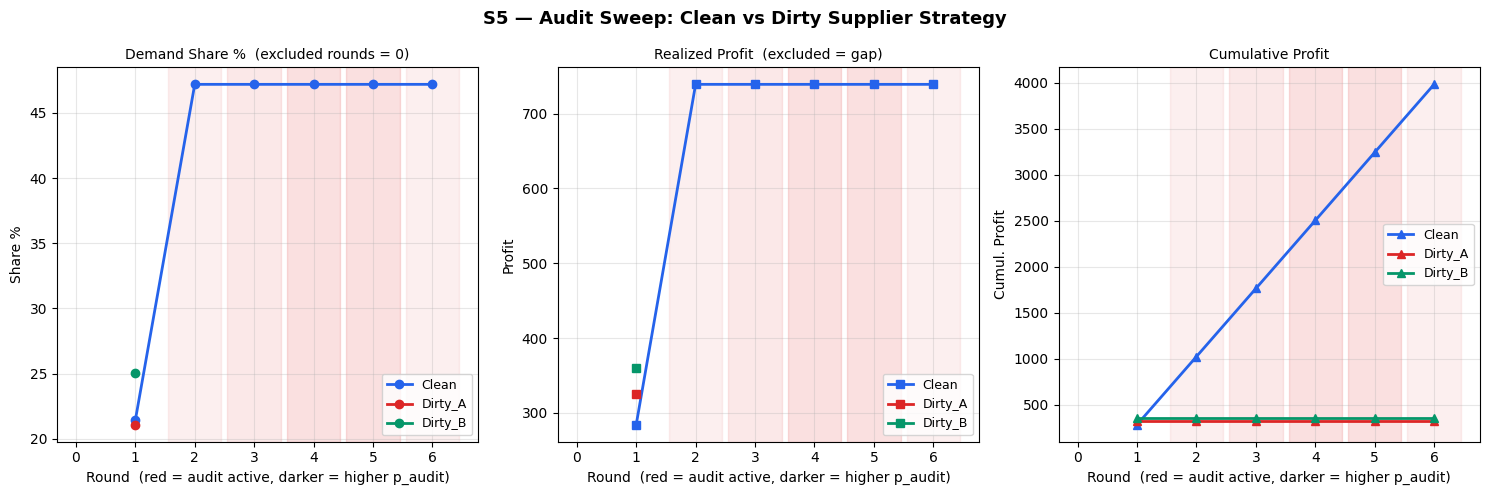

S5 audit chart saved.


In [9]:
# ── Audit Sweep visualization ─────────────────────────────────────────────
fig5, axes5 = plt.subplots(1, 3, figsize=(15, 5))
fig5.suptitle('S5 — Audit Sweep: Clean vs Dirty Supplier Strategy',
              fontsize=13, fontweight='bold')

teams5  = sorted(s5_r['team'].unique())
colors5 = team_colors(teams5)
rounds5 = sorted(s5_r['round_no'].unique())

for team in teams5:
    td     = s5_r[s5_r['team'] == team].sort_values('round_no')
    profit = td['realized_profit'].where(~td['audit_excluded'], other=float('nan')).values
    share  = td['demand_share_pct'].where(~td['audit_excluded'], other=float('nan')).values
    cum    = td['cum_profit'].values
    rnds   = td['round_no'].values
    axes5[0].plot(rnds, share,  marker='o', label=team, color=colors5[team], linewidth=2)
    axes5[1].plot(rnds, profit, marker='s', label=team, color=colors5[team], linewidth=2)
    axes5[2].plot(rnds, cum,    marker='^', label=team, color=colors5[team], linewidth=2)
    # Mark rounds where this team was excluded
    excl_rnds = td[td['audit_excluded']]['round_no'].values
    for ax in axes5:
        ax.axvspan(0, 0, alpha=0, color=colors5[team])  # placeholder for legend alignment

# Shade rounds with active audit
for ax in axes5:
    for r in rounds5:
        ap = ap_by_rno.get(r, 0)
        if ap > 0:
            ax.axvspan(r - 0.45, r + 0.45, alpha=0.04 + 0.10 * ap, color='#dc2626', zorder=0)

for ax, title, ylabel in zip(axes5,
    ['Demand Share %  (excluded rounds = 0)',
     'Realized Profit  (excluded = gap)',
     'Cumulative Profit'],
    ['Share %', 'Profit', 'Cumul. Profit']):
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Round  (red = audit active, darker = higher p_audit)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('s5_audit_sweep.png', dpi=120, bbox_inches='tight'); plt.show()
print('S5 audit chart saved.')


## Visualizations
### Time-Series: Profit / Cumulative / Share / Price

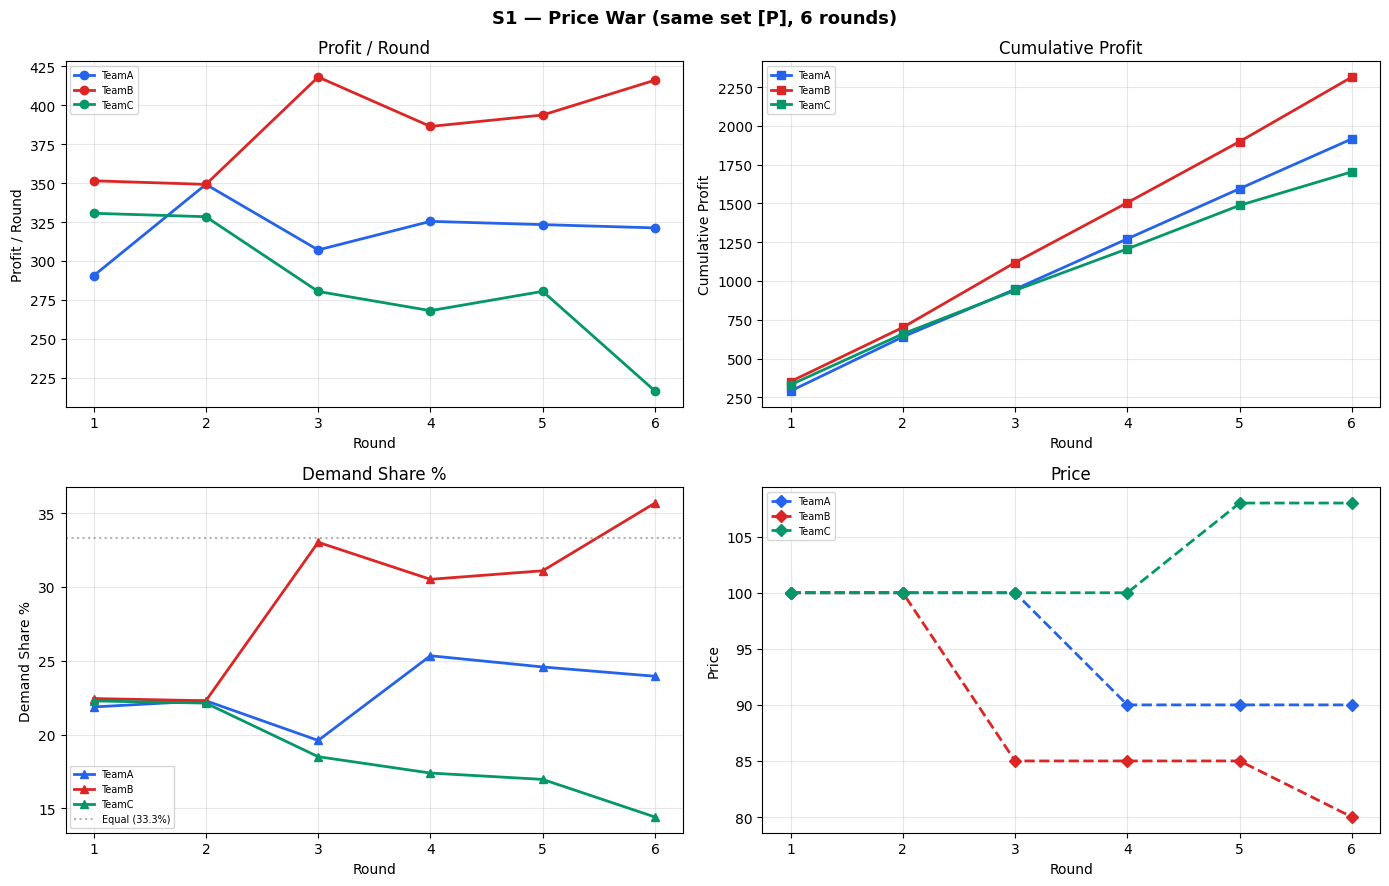

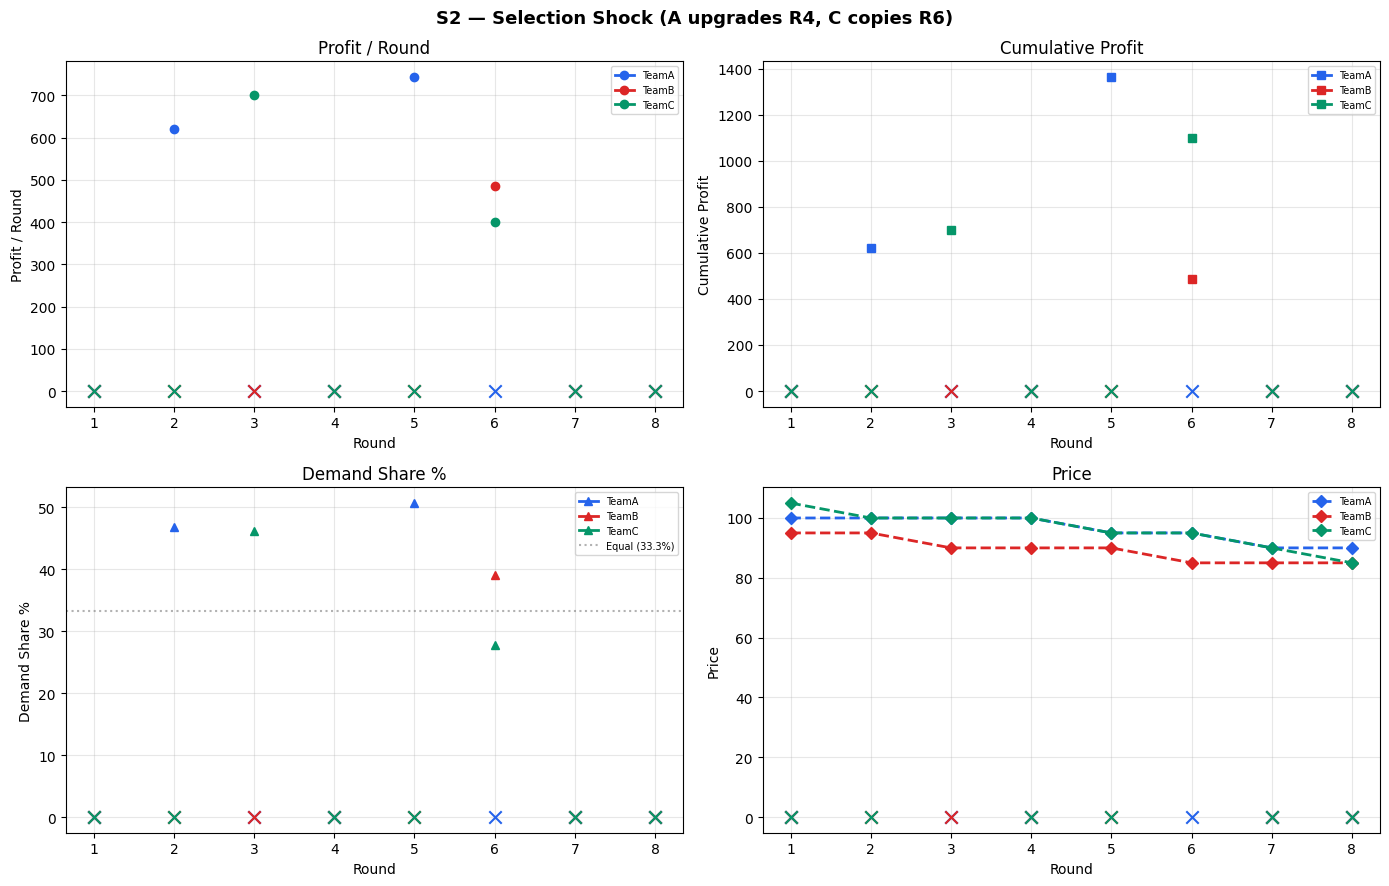

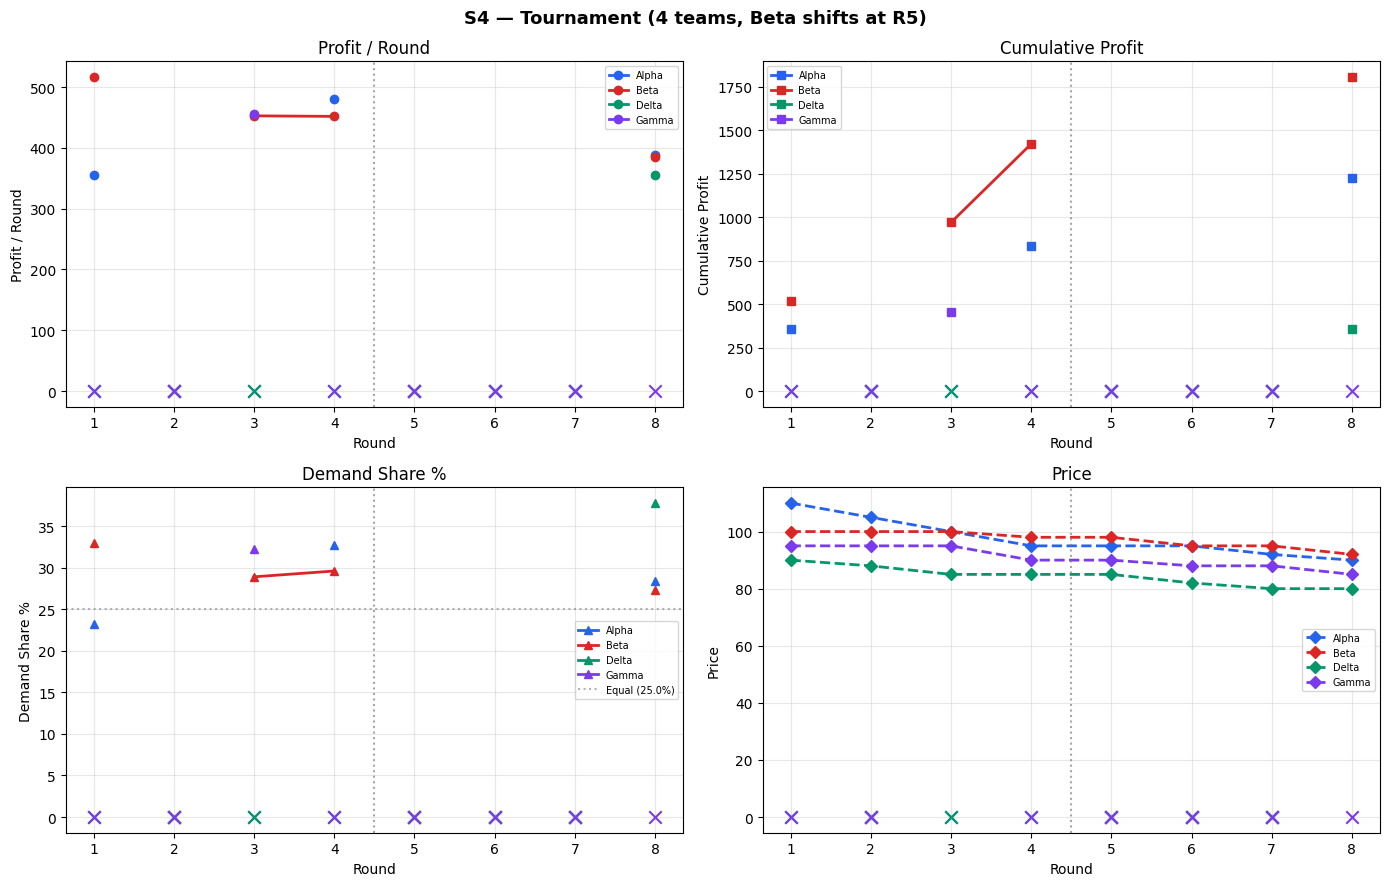

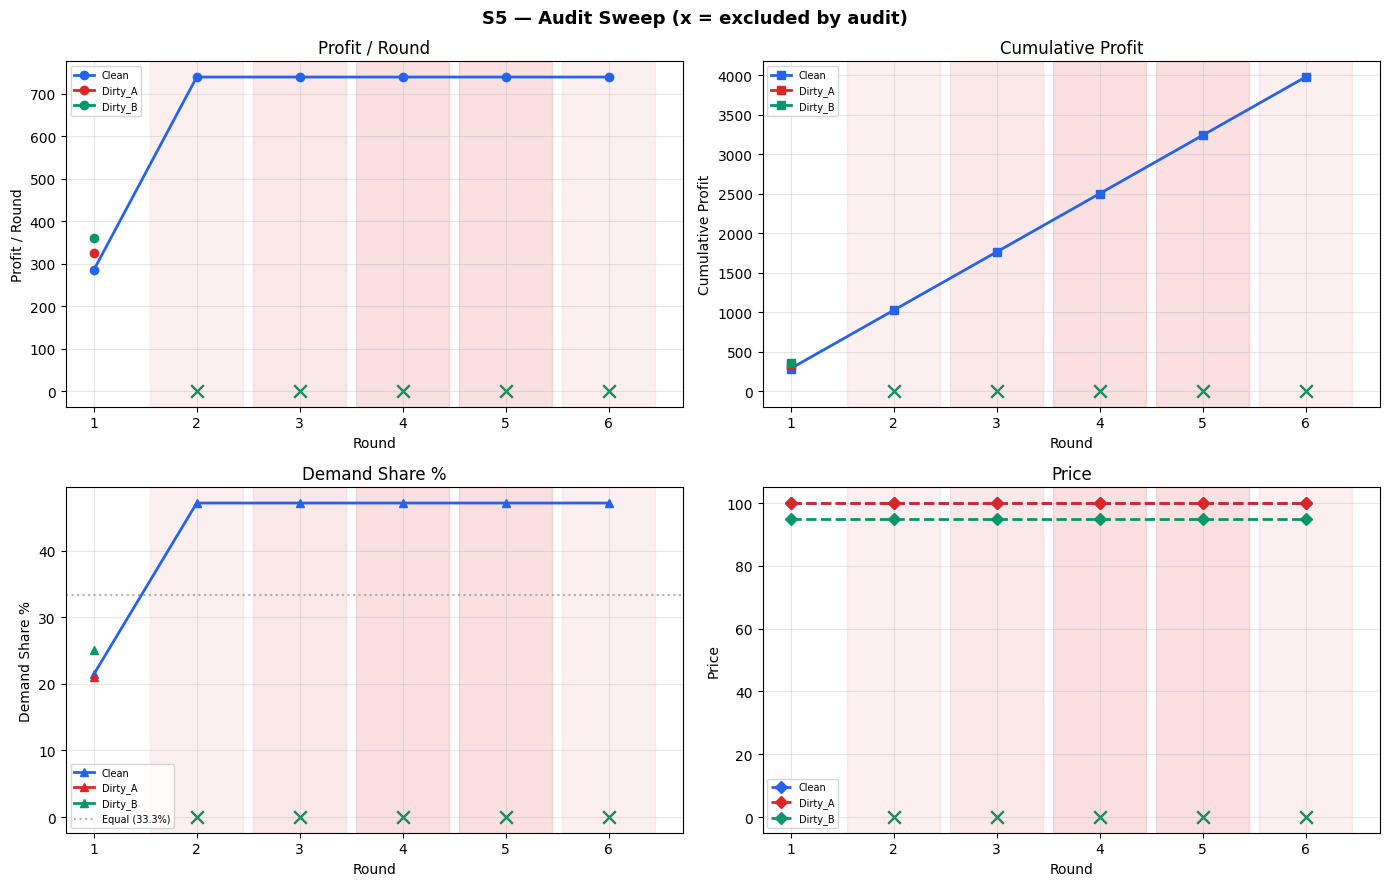

Time-series done.


In [10]:
def plot_ts(df, title, figsize=(14,9)):
    teams = sorted(df['team'].unique()); colors = team_colors(teams)
    has_audit = 'audit_excluded' in df.columns
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    specs_list = [
        ('realized_profit',  'Profit / Round',       'o', '-'),
        ('cum_profit',       'Cumulative Profit',    's', '-'),
        ('demand_share_pct', 'Demand Share %',       '^', '-'),
        ('price',            'Price',                'D', '--'),
    ]
    for ax, (col, ylabel, marker, ls) in zip(axes.flat, specs_list):
        for team in teams:
            td = df[df['team']==team].sort_values('round_no')
            if has_audit and col != 'price':
                vals = td[col].where(~td['audit_excluded'], other=float('nan'))
            else:
                vals = td[col]
            ax.plot(td['round_no'], vals, marker=marker, label=team,
                    color=colors[team], linewidth=2, linestyle=ls)
            if has_audit:
                excl = td[td['audit_excluded']]
                ax.scatter(excl['round_no'], [0]*len(excl),
                           marker='x', color=colors[team], s=80, zorder=5)
        if col == 'demand_share_pct':
            ax.axhline(100/len(teams), color='gray', linestyle=':', alpha=0.6,
                       label=f'Equal ({100/len(teams):.1f}%)')
        ax.set_title(ylabel); ax.set_xlabel('Round'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    return fig

fig1 = plot_ts(s1_r, 'S1 — Price War (same set [P], 6 rounds)')
plt.savefig('s1_timeseries.png', dpi=120, bbox_inches='tight'); plt.show()

fig2 = plot_ts(s2_r, 'S2 — Selection Shock (A upgrades R4, C copies R6)')
plt.savefig('s2_timeseries.png', dpi=120, bbox_inches='tight'); plt.show()

fig4 = plot_ts(s4_r, 'S4 — Tournament (4 teams, Beta shifts at R5)')
for ax in fig4.get_axes():
    ax.axvline(4.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
plt.savefig('s4_timeseries.png', dpi=120, bbox_inches='tight'); plt.show()

fig5 = plot_ts(s5_r, 'S5 — Audit Sweep (x = excluded by audit)')
ap_by_rno = {sch['round_no']: sch['audit_prob'] for sch in AUDIT_SCHEDULE}
for ax in fig5.get_axes():
    for r, ap in ap_by_rno.items():
        if ap > 0:
            ax.axvspan(r - 0.45, r + 0.45, alpha=0.04 + 0.10*ap, color='#dc2626', zorder=0)
plt.savefig('s5_timeseries.png', dpi=120, bbox_inches='tight'); plt.show()
print('Time-series done.')


### Pie Charts — Demand Share by Round

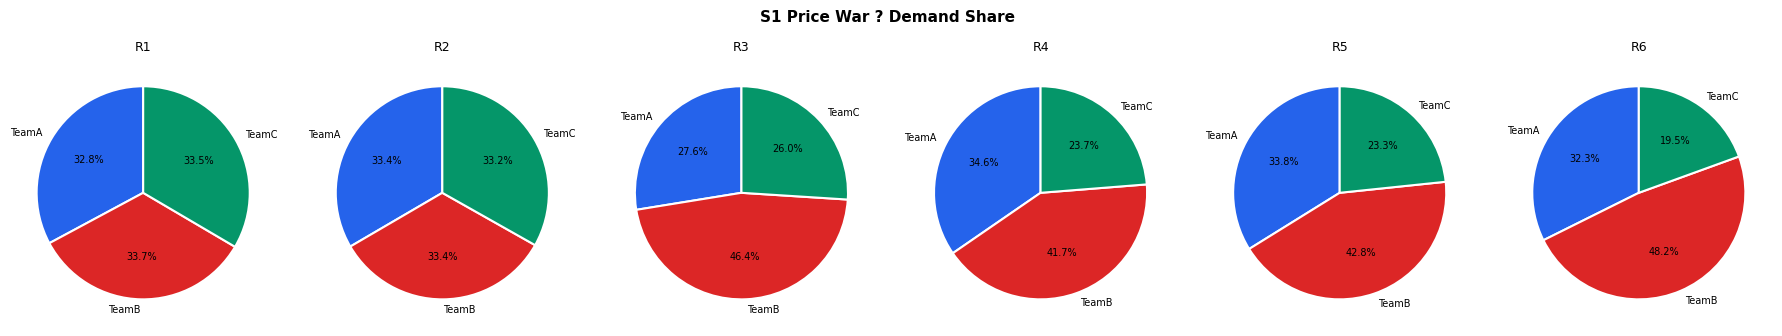

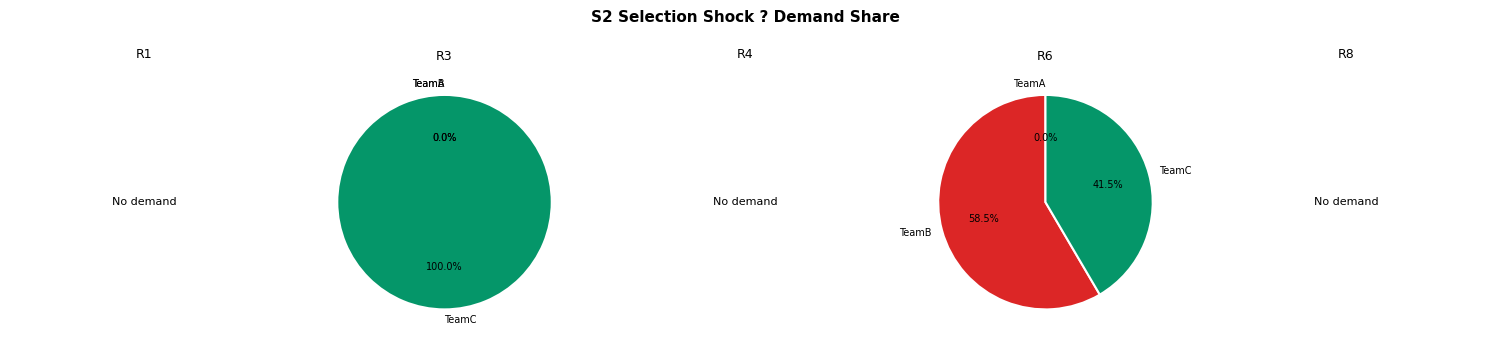

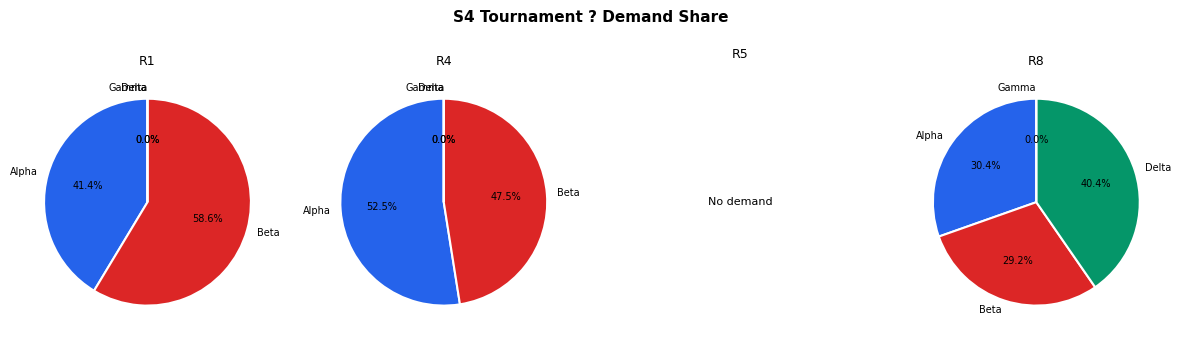

Pies done.


In [11]:
def plot_pies(df, scenario_name, rounds=None):
    if rounds is None: rounds = sorted(df['round_no'].unique())
    n = len(rounds)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3.5))
    if n == 1: axes = [axes]
    fig.suptitle(f'{scenario_name} ? Demand Share', fontsize=11, fontweight='bold')
    teams = sorted(df['team'].unique())
    color_map = {team: PALETTE[i % len(PALETTE)] for i, team in enumerate(teams)}
    wedge = {'edgecolor':'white','linewidth':1.5}
    for ax, rno in zip(axes, rounds):
        rd = df[df['round_no']==rno].sort_values('team')
        shares = pd.to_numeric(rd['demand_share_pct'], errors='coerce').fillna(0.0).clip(lower=0.0).to_numpy()
        lbls = [t.split('[')[0].strip() or t for t in rd['team'].values]
        if len(shares) == 0 or not np.isfinite(shares).all() or float(shares.sum()) <= 1e-12:
            ax.text(0.5, 0.5, 'No demand', ha='center', va='center', fontsize=8)
            ax.set_axis_off()
        else:
            colors = [color_map[t] for t in rd['team'].values]
            ax.pie(shares, labels=lbls, colors=colors, autopct='%1.1f%%',
                   startangle=90, wedgeprops=wedge, textprops={'fontsize':7})
        ax.set_title(f'R{rno}', fontsize=9)
    plt.tight_layout()
    return fig

plot_pies(s1_r, 'S1 Price War', [1,2,3,4,5,6])
plt.savefig('s1_pies.png', dpi=110, bbox_inches='tight'); plt.show()

plot_pies(s2_r, 'S2 Selection Shock', [1,3,4,6,8])
plt.savefig('s2_pies.png', dpi=110, bbox_inches='tight'); plt.show()

plot_pies(s4_r, 'S4 Tournament', [1,4,5,8])
plt.savefig('s4_pies.png', dpi=110, bbox_inches='tight'); plt.show()
print('Pies done.')


### Per-Segment Heatmaps (MNL share × segment, one round at a time)

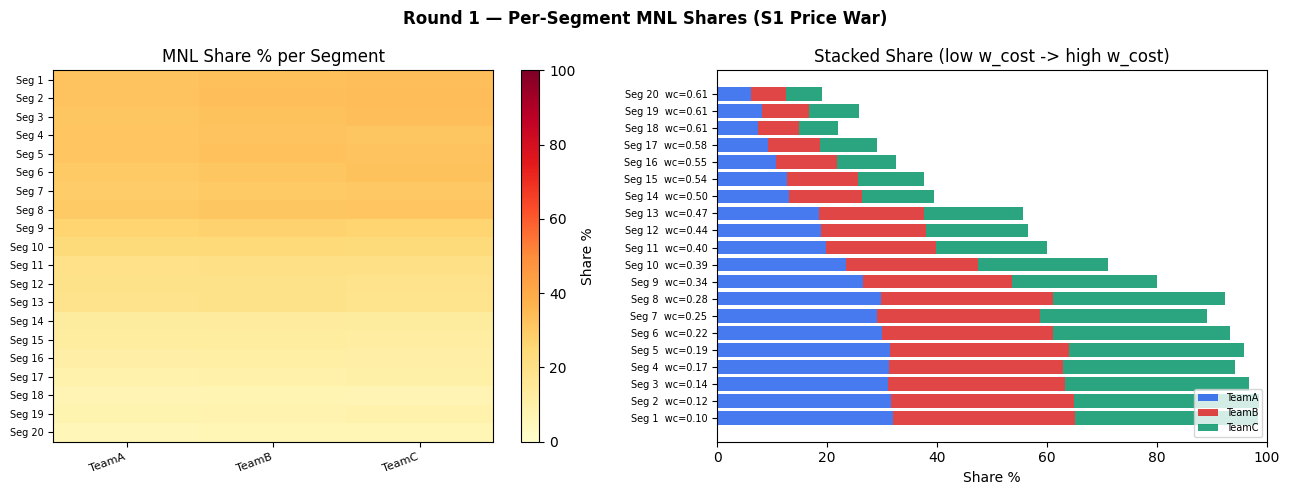

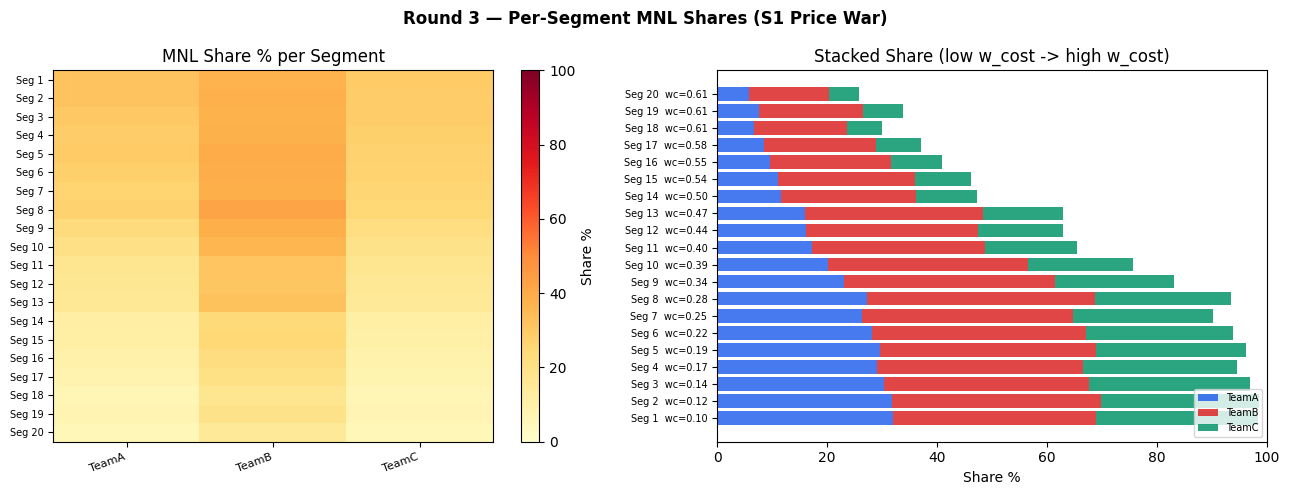

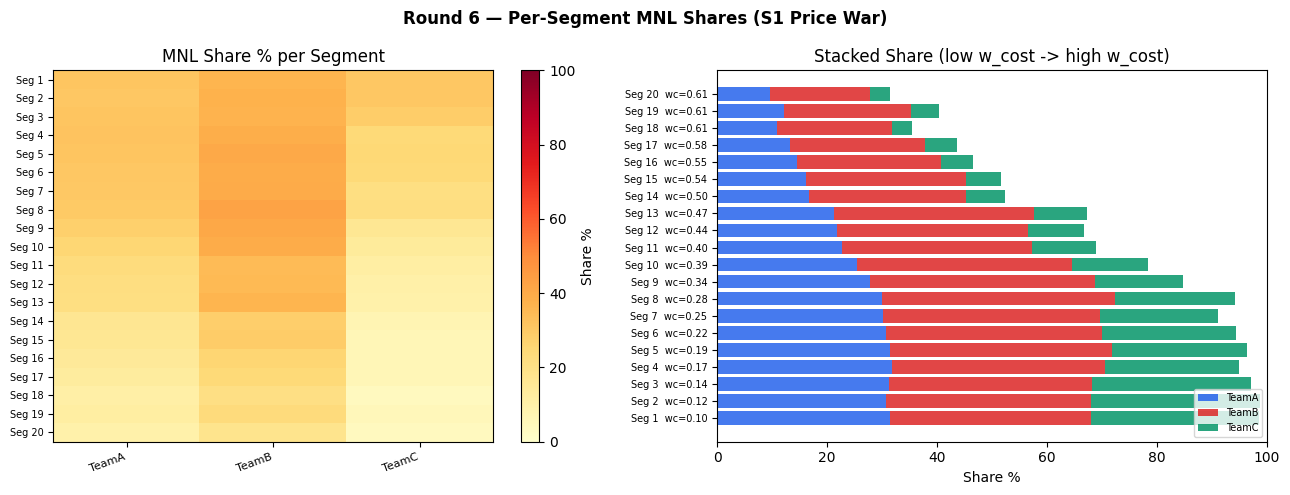

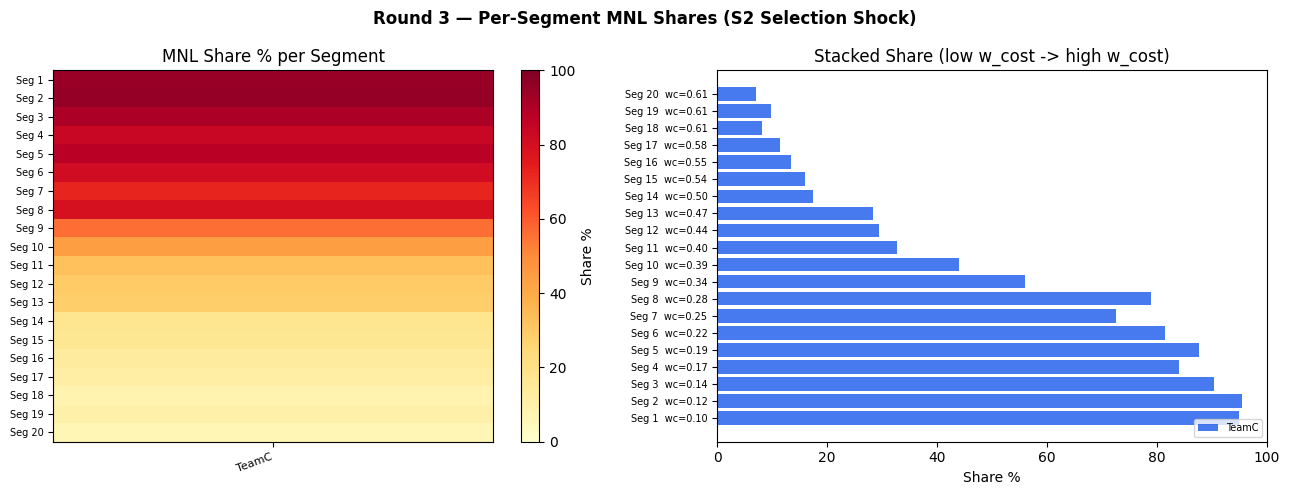

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

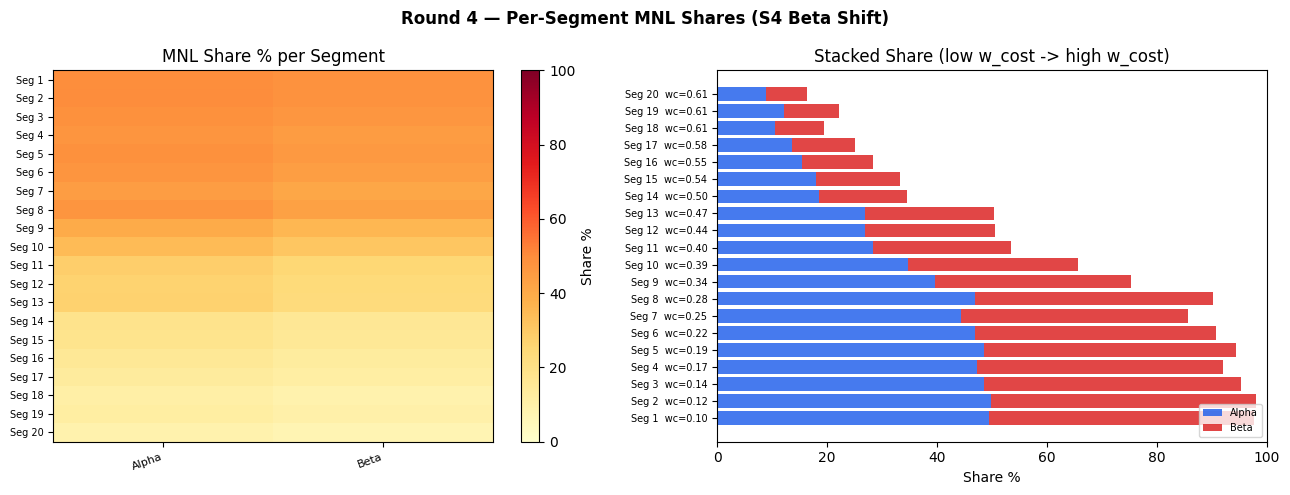

<Figure size 640x480 with 0 Axes>

Heatmaps done.


In [12]:
def plot_seg_heatmap(sdf, rnd, title_sfx=''):
    rd = sdf[sdf['round_no']==rnd].copy().sort_values('segment_index')
    if rd.empty: return
    teams = sorted(rd['team'].unique())
    pivot = rd.pivot_table(index='segment_index', columns='team',
                            values='mnl_share_pct', aggfunc='first')[teams]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Round {rnd} — Per-Segment MNL Shares {title_sfx}',
                 fontsize=12, fontweight='bold')
    # heatmap
    im = ax1.imshow(pivot.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)
    ax1.set_xticks(range(len(teams)))
    ax1.set_xticklabels(teams, rotation=20, ha='right', fontsize=8)
    ax1.set_yticks(range(len(pivot)))
    ax1.set_yticklabels([f'Seg {i}' for i in pivot.index], fontsize=7)
    ax1.set_title('MNL Share % per Segment')
    plt.colorbar(im, ax=ax1, label='Share %')
    # stacked bar
    wcosts = rd.drop_duplicates('segment_index').sort_values('segment_index')['w_cost'].values
    bottom = np.zeros(len(pivot))
    for j, team in enumerate(teams):
        vals = pivot[team].fillna(0).values
        ax2.barh(range(len(pivot)), vals, left=bottom,
                 label=team, color=PALETTE[j%len(PALETTE)], alpha=0.85)
        bottom += vals
    ax2.set_yticks(range(len(pivot)))
    ax2.set_yticklabels([f'Seg {i}  wc={wc:.2f}' for i,wc in zip(pivot.index,wcosts)], fontsize=7)
    ax2.set_xlabel('Share %')
    ax2.set_title('Stacked Share (low w_cost -> high w_cost)')
    ax2.legend(fontsize=7, loc='lower right'); ax2.set_xlim(0,100)
    plt.tight_layout()
    return fig

# S1: before, during, after price war
for rno in [1, 3, 6]:
    plot_seg_heatmap(s1_s, rno, '(S1 Price War)')
    plt.savefig(f's1_seg_r{rno}.png', dpi=100, bbox_inches='tight'); plt.show()

# S2: just before and just after selection upgrade
for rno in [3, 4, 8]:
    plot_seg_heatmap(s2_s, rno, '(S2 Selection Shock)')
    plt.savefig(f's2_seg_r{rno}.png', dpi=100, bbox_inches='tight'); plt.show()

# S4: last Bell round vs first QualPref round
for rno in [4, 5]:
    plot_seg_heatmap(s4_s, rno, '(S4 Beta Shift)')
    plt.savefig(f's4_seg_r{rno}.png', dpi=100, bbox_inches='tight'); plt.show()
print('Heatmaps done.')


### Delta Sweep — Price Sensitivity Chart

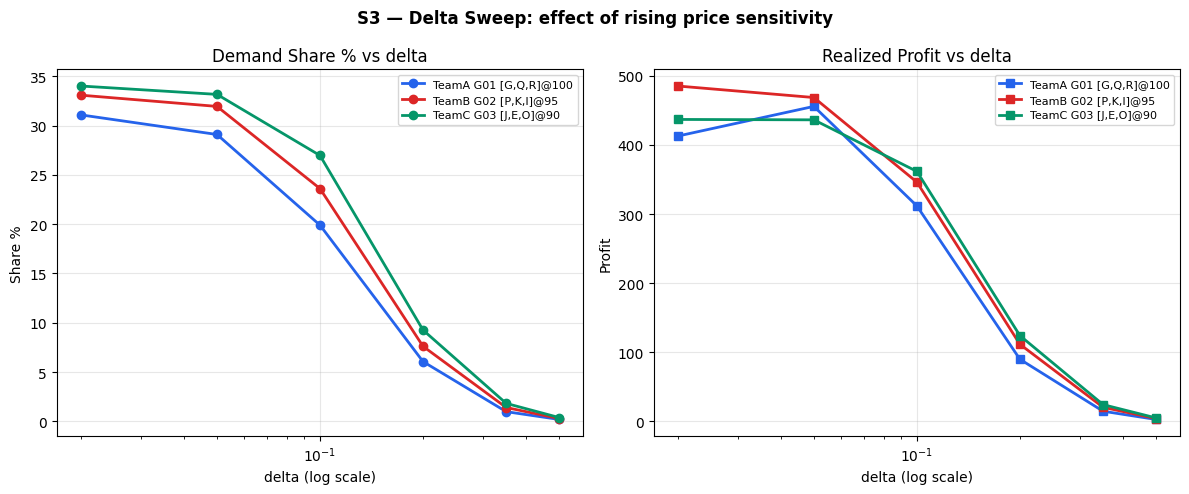

Delta chart done.


In [13]:
fig_d, axes = plt.subplots(1, 2, figsize=(12, 5))
fig_d.suptitle('S3 — Delta Sweep: effect of rising price sensitivity',
               fontsize=12, fontweight='bold')
teams = sorted(s3_r['team'].unique()); colors = team_colors(teams)
for team in teams:
    td = s3_r[s3_r['team']==team].sort_values('delta')
    axes[0].plot(td['delta'], td['demand_share_pct'], marker='o',
                 label=team, color=colors[team], linewidth=2)
    axes[1].plot(td['delta'], td['realized_profit'], marker='s',
                 label=team, color=colors[team], linewidth=2)
for ax, title, ylabel in zip(axes,
    ['Demand Share % vs delta','Realized Profit vs delta'],
    ['Share %','Profit']):
    ax.set_title(title); ax.set_xlabel('delta (log scale)')
    ax.set_ylabel(ylabel); ax.set_xscale('log')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('s3_delta.png', dpi=120, bbox_inches='tight'); plt.show()
print('Delta chart done.')


### Utility Time-Series — All Scenarios

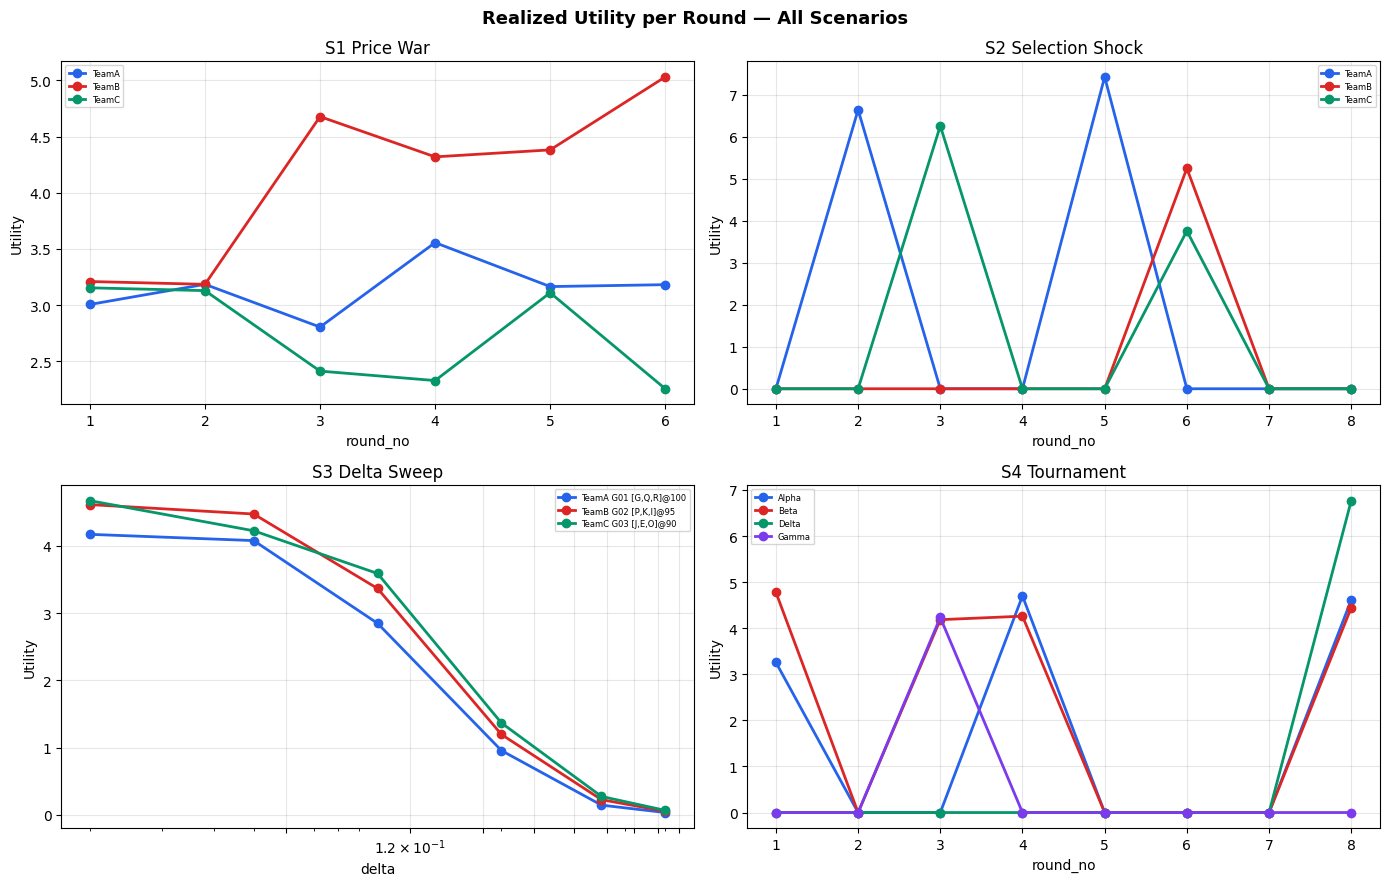

Utility charts done.


In [14]:
fig_u, axes = plt.subplots(2, 2, figsize=(14,9))
fig_u.suptitle('Realized Utility per Round — All Scenarios', fontsize=13, fontweight='bold')
for ax, (df, label, xcol) in zip(axes.flat, [
    (s1_r,'S1 Price War',       'round_no'),
    (s2_r,'S2 Selection Shock', 'round_no'),
    (s3_r,'S3 Delta Sweep',     'delta'),
    (s4_r,'S4 Tournament',      'round_no'),
]):
    teams = sorted(df['team'].unique()); colors = team_colors(teams)
    for team in teams:
        td = df[df['team']==team].sort_values(xcol)
        ax.plot(td[xcol], td['realized_utility'], marker='o',
                label=team, color=colors[team], linewidth=2)
    ax.set_title(label); ax.set_xlabel(xcol); ax.set_ylabel('Utility')
    if xcol == 'delta': ax.set_xscale('log')
    ax.legend(fontsize=6); ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('all_utility.png', dpi=120, bbox_inches='tight'); plt.show()
print('Utility charts done.')


## Export to Excel

In [15]:
OUTPUT = Path('round_simulation_results.xlsx')

def profit_pivot(df):
    return df.pivot_table(index='team', columns='round_no',
                          values='realized_profit', aggfunc='first').round(1)
def cum_pivot(df):
    return df.pivot_table(index='team', columns='round_no',
                          values='cum_profit', aggfunc='last').round(1)
def share_pivot(df):
    return df.pivot_table(index='team', columns='round_no',
                          values='demand_share_pct', aggfunc='first').round(2)
def utility_pivot(df):
    return df.pivot_table(index='team', columns='round_no',
                          values='realized_utility', aggfunc='first').round(3)
def seg_avg(sdf):
    return sdf.groupby(['segment_index','team'])['mnl_share_pct'].mean().unstack().round(2)
def seg_rnd(sdf, rno):
    return sdf[sdf['round_no']==rno].pivot_table(
        index='segment_index', columns='team',
        values='mnl_share_pct', aggfunc='first').round(2)

with pd.ExcelWriter(OUTPUT, engine='openpyxl') as w:
    # Raw data
    s1_r.to_excel(w, sheet_name='S1_Rounds',      index=False)
    s1_s.to_excel(w, sheet_name='S1_Segments',    index=False)
    s2_r.to_excel(w, sheet_name='S2_Rounds',      index=False)
    s2_s.to_excel(w, sheet_name='S2_Segments',    index=False)
    s3_r.to_excel(w, sheet_name='S3_Rounds',      index=False)
    s3_s.to_excel(w, sheet_name='S3_Segments',    index=False)
    s4_r.to_excel(w, sheet_name='S4_Rounds',      index=False)
    s4_s.to_excel(w, sheet_name='S4_Segments',    index=False)
    s5_r.to_excel(w, sheet_name='S5_AuditSweep_Rounds', index=False)
    (s5_s.to_excel(w, sheet_name='S5_AuditSweep_Segs', index=False) if not s5_s.empty else None)
    # Pivots
    profit_pivot(s1_r).to_excel(w,  sheet_name='S1_Profit_Pivot')
    cum_pivot(s1_r).to_excel(w,     sheet_name='S1_CumProfit_Pivot')
    share_pivot(s1_r).to_excel(w,   sheet_name='S1_Share_Pivot')
    utility_pivot(s1_r).to_excel(w, sheet_name='S1_Utility_Pivot')
    profit_pivot(s2_r).to_excel(w,  sheet_name='S2_Profit_Pivot')
    cum_pivot(s2_r).to_excel(w,     sheet_name='S2_CumProfit_Pivot')
    share_pivot(s2_r).to_excel(w,   sheet_name='S2_Share_Pivot')
    profit_pivot(s4_r).to_excel(w,  sheet_name='S4_Profit_Pivot')
    cum_pivot(s4_r).to_excel(w,     sheet_name='S4_CumProfit_Pivot')
    share_pivot(s4_r).to_excel(w,   sheet_name='S4_Share_Pivot')
    # Segment breakdowns
    seg_avg(s1_s).to_excel(w,      sheet_name='S1_SegShare_AllRnd_Avg')
    seg_avg(s2_s).to_excel(w,      sheet_name='S2_SegShare_AllRnd_Avg')
    seg_avg(s4_s).to_excel(w,      sheet_name='S4_SegShare_AllRnd_Avg')
    seg_rnd(s1_s,1).to_excel(w,   sheet_name='S1_Seg_R1_Baseline')
    seg_rnd(s1_s,3).to_excel(w,   sheet_name='S1_Seg_R3_PriceCut')
    seg_rnd(s1_s,6).to_excel(w,   sheet_name='S1_Seg_R6_Final')
    seg_rnd(s2_s,3).to_excel(w,   sheet_name='S2_Seg_R3_BeforeUpgrade')
    seg_rnd(s2_s,4).to_excel(w,   sheet_name='S2_Seg_R4_AfterUpgrade')
    seg_rnd(s4_s,4).to_excel(w,   sheet_name='S4_Seg_R4_Bell')
    seg_rnd(s4_s,5).to_excel(w,   sheet_name='S4_Seg_R5_QualPref')

print(f'Saved -> {OUTPUT.resolve()}')
print(f'Total raw rows: {sum(len(d) for d in [s1_r,s1_s,s2_r,s2_s,s3_r,s3_s,s4_r,s4_s,s5_r,s5_s])}')


Saved -> C:\Users\LENOVO\Desktop\Asistan\Arya Phone\arya_fullstack_app\server\tests\round_simulation_results.xlsx
Total raw rows: 1270


## Summary

In [16]:
print('='*65)
print('SIMULATION SUMMARY')
print('='*65)
for label, df in [('S1 Price War',s1_r),('S2 Selection Shock',s2_r),
                   ('S3 Delta Sweep',s3_r),('S4 Tournament',s4_r),
                   ('S5 Audit Sweep', s5_r)]:
    final = df.groupby('team')['realized_profit'].sum().sort_values(ascending=False)
    print(f'\n{label} - Total Profit Ranking:')
    for team, profit in final.items():
        avg_share = df[df['team']==team]['demand_share_pct'].mean()
        print(f'  {team:<38s} profit={profit:7.0f}  avg_share={avg_share:.1f}%')

print('\nS3 - lowest-price team vs delta:')
tc = s3_r[s3_r['team'].str.contains('@90')].sort_values('round_no')
for _, row in tc.iterrows():
    print(f'  delta={row["delta"]:.2f}  share={row["demand_share_pct"]:.1f}%  profit={row["realized_profit"]:.0f}  picks={row["picks"]}')


SIMULATION SUMMARY

S1 Price War - Total Profit Ranking:
  TeamB                                  profit=   2315  avg_share=29.2%
  TeamA                                  profit=   1917  avg_share=22.9%
  TeamC                                  profit=   1704  avg_share=18.6%

S2 Selection Shock - Total Profit Ranking:
  TeamA                                  profit=   1364  avg_share=12.2%
  TeamC                                  profit=   1101  avg_share=9.2%
  TeamB                                  profit=    486  avg_share=4.9%

S3 Delta Sweep - Total Profit Ranking:
  TeamB G02 [P,K,I]@95                   profit=   1436  avg_share=16.3%
  TeamC G03 [J,E,O]@90                   profit=   1389  avg_share=17.6%
  TeamA G01 [G,Q,R]@100                  profit=   1288  avg_share=14.6%

S4 Tournament - Total Profit Ranking:
  Beta                                   profit=   1806  avg_share=14.9%
  Alpha                                  profit=   1224  avg_share=10.6%
  Gamma            